# BUSSINESS PROBLEM 

A company may have many customers, but not all customers spend money in the same way. Some customers spend frequently, some spend less, some prefer online shopping, while others spend more through offline purchases.

It can be difficult for the company to understand these different spending patterns by looking at individual customers.

This project aims to **group customers with similar spending behaviors into meaningful segments** using clustering techniques such as **K-Means and DBSCAN**.

These segments can help the company understand customer spending patterns and make better decisions about **marketing, discounts, customer engagement, and personalized offers**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv(r"C:\Users\rithikagogi\Downloads\Spending_Behavior_Segmentation_2200.csv")
df

,Customer_ID,Age,Gender,Monthly_Income,Monthly_Spending,Purchase_Frequency,Average_Purchase_Amount,Online_Spending,Offline_Spending,Savings,Discount_Usage_Percent
0,C0001,56,Female,42275.0,20454.0,7.0,2986,15205,5249,22179.0,38
1,C0002,46,Female,52496.0,9156.0,7.0,1727,4095,5061,45286.0,0
2,C0003,32,Male,50419.0,9291.0,9.0,1261,6412,2879,47642.0,42
3,C0004,60,Female,76410.0,6972.0,9.0,846,1876,5096,69254.0,64
4,C0005,25,Female,47982.0,20430.0,11.0,1898,14891,5539,39497.0,56
...,...,...,...,...,...,...,...,...,...,...,...
2195,C2196,31,Male,42035.0,9415.0,6.0,1882,4774,4641,37167.0,28
2196,C2197,53,Female,61669.0,12222.0,7.0,1915,7179,5043,59100.0,27
2197,C2198,50,Female,18039.0,18348.0,8.0,2363,12627,5721,9805.0,0
2198,C2199,40,Female,55884.0,6338.0,5.0,1233,3974,2364,57236.0,38


In [6]:
df.head()

,Customer_ID,Age,Gender,Monthly_Income,Monthly_Spending,Purchase_Frequency,Average_Purchase_Amount,Online_Spending,Offline_Spending,Savings,Discount_Usage_Percent
0,C0001,56,Female,42275.0,20454.0,7.0,2986,15205,5249,22179.0,38
1,C0002,46,Female,52496.0,9156.0,7.0,1727,4095,5061,45286.0,0
2,C0003,32,Male,50419.0,9291.0,9.0,1261,6412,2879,47642.0,42
3,C0004,60,Female,76410.0,6972.0,9.0,846,1876,5096,69254.0,64
4,C0005,25,Female,47982.0,20430.0,11.0,1898,14891,5539,39497.0,56


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              2200 non-null   object 
 1   Age                      2200 non-null   int64  
 2   Gender                   2200 non-null   object 
 3   Monthly_Income           2178 non-null   float64
 4   Monthly_Spending         2178 non-null   float64
 5   Purchase_Frequency       2178 non-null   float64
 6   Average_Purchase_Amount  2200 non-null   int64  
 7   Online_Spending          2200 non-null   int64  
 8   Offline_Spending         2200 non-null   int64  
 9   Savings                  2178 non-null   float64
 10  Discount_Usage_Percent   2200 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 189.2+ KB


In [5]:
df.shape

(2200, 11)

In [9]:
df.dtypes

Customer_ID                 object
Age                          int64
Gender                      object
Monthly_Income             float64
Monthly_Spending           float64
Purchase_Frequency         float64
Average_Purchase_Amount      int64
Online_Spending              int64
Offline_Spending             int64
Savings                    float64
Discount_Usage_Percent       int64
dtype: object

In [13]:
df.isnull().sum()

Customer_ID                 0
Age                         0
Gender                      0
Monthly_Income             22
Monthly_Spending           22
Purchase_Frequency         22
Average_Purchase_Amount     0
Online_Spending             0
Offline_Spending            0
Savings                    22
Discount_Usage_Percent      0
dtype: int64

In [16]:
df['Monthly_Income'] = df['Monthly_Income'].fillna(df['Monthly_Income'].median())
df['Monthly_Spending'] = df['Monthly_Spending'].fillna(df['Monthly_Spending'].median())
df['Purchase_Frequency'] = df['Purchase_Frequency'].fillna(df['Purchase_Frequency'].median())
df['Savings'] = df['Savings'].fillna(df['Savings'].median())

In [17]:
df.isnull().sum()

Customer_ID                0
Age                        0
Gender                     0
Monthly_Income             0
Monthly_Spending           0
Purchase_Frequency         0
Average_Purchase_Amount    0
Online_Spending            0
Offline_Spending           0
Savings                    0
Discount_Usage_Percent     0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [20]:
features = [
    'Monthly_Income',
    'Monthly_Spending',
    'Purchase_Frequency',
    'Average_Purchase_Amount',
    'Online_Spending',
    'Offline_Spending',
    'Savings',
    'Discount_Usage_Percent'
]

x= df[features]

In [21]:
x.head()

,Monthly_Income,Monthly_Spending,Purchase_Frequency,Average_Purchase_Amount,Online_Spending,Offline_Spending,Savings,Discount_Usage_Percent
0,42275.0,20454.0,7.0,2986,15205,5249,22179.0,38
1,52496.0,9156.0,7.0,1727,4095,5061,45286.0,0
2,50419.0,9291.0,9.0,1261,6412,2879,47642.0,42
3,76410.0,6972.0,9.0,846,1876,5096,69254.0,64
4,47982.0,20430.0,11.0,1898,14891,5539,39497.0,56


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [23]:
x_scaled.shape

(2200, 8)

# K-Means

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

C:\Users\rithikagogi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\rithikagogi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\rithikagogi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\rithikagogi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have

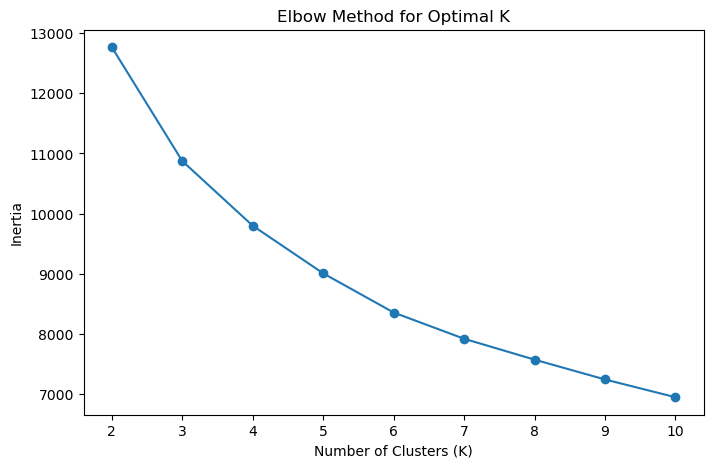

In [26]:
plt.figure(figsize=(8,5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

In [28]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x_scaled)

    score = silhouette_score(x_scaled, labels)
    silhouette_scores.append(score)

C:\Users\rithikagogi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\rithikagogi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\rithikagogi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\rithikagogi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have

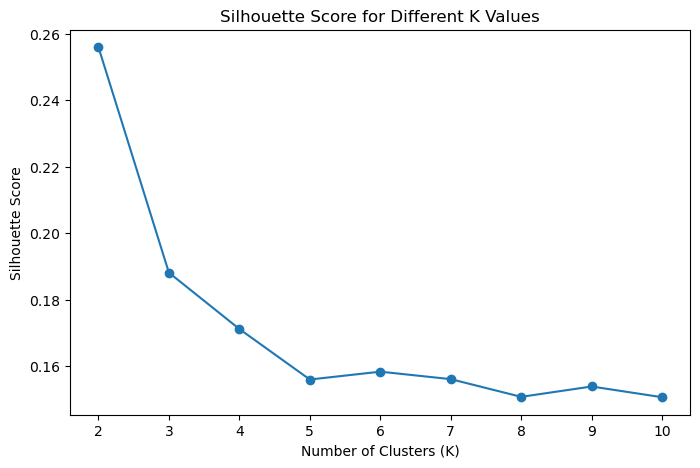

In [29]:
plt.figure(figsize=(8,5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

In [31]:
# Final K-Means model

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(x_scaled)


C:\Users\rithikagogi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


In [32]:
df['Cluster'] = clusters

In [33]:
df.head()

,Customer_ID,Age,Gender,Monthly_Income,Monthly_Spending,Purchase_Frequency,Average_Purchase_Amount,Online_Spending,Offline_Spending,Savings,Discount_Usage_Percent,Cluster
0,C0001,56,Female,42275.0,20454.0,7.0,2986,15205,5249,22179.0,38,3
1,C0002,46,Female,52496.0,9156.0,7.0,1727,4095,5061,45286.0,0,0
2,C0003,32,Male,50419.0,9291.0,9.0,1261,6412,2879,47642.0,42,0
3,C0004,60,Female,76410.0,6972.0,9.0,846,1876,5096,69254.0,64,0
4,C0005,25,Female,47982.0,20430.0,11.0,1898,14891,5539,39497.0,56,2


In [34]:
df['Cluster'].value_counts().sort_index()

Cluster
0    570
1    699
2    592
3    339
Name: count, dtype: int64

In [35]:
cluster_summary = df.groupby('Cluster')[features].mean()

cluster_summary

,Monthly_Income,Monthly_Spending,Purchase_Frequency,Average_Purchase_Amount,Online_Spending,Offline_Spending,Savings,Discount_Usage_Percent
Cluster,,,,,,,,
0,58637.403509,7125.170175,6.852632,1285.719298,3539.629825,3569.249123,56409.235088,34.636842
1,30068.406295,9817.009299,7.244635,1604.357654,4942.922747,4854.363376,25116.931330,34.635193
2,55108.523649,15622.022804,8.300676,2183.233108,7860.062500,7835.643581,44488.163851,34.993243
3,39006.138643,24900.823009,10.941003,2401.082596,12594.914454,12372.395280,19748.828909,36.448378


In [36]:
cluster_summary = df.groupby('Cluster')[features].mean().round(2)

print(cluster_summary)

         Monthly_Income  Monthly_Spending  Purchase_Frequency  \
Cluster                                                         
0              58637.40           7125.17                6.85   
1              30068.41           9817.01                7.24   
2              55108.52          15622.02                8.30   
3              39006.14          24900.82               10.94   

         Average_Purchase_Amount  Online_Spending  Offline_Spending   Savings  \
Cluster                                                                         
0                        1285.72          3539.63           3569.25  56409.24   
1                        1604.36          4942.92           4854.36  25116.93   
2                        2183.23          7860.06           7835.64  44488.16   
3                        2401.08         12594.91          12372.40  19748.83   

         Discount_Usage_Percent  
Cluster                          
0                         34.64  
1                   

In [37]:
cluster_size = df['Cluster'].value_counts().sort_index()

print(cluster_size)

Cluster
0    570
1    699
2    592
3    339
Name: count, dtype: int64


In [38]:
df.groupby('Cluster')[
    ['Monthly_Income',
     'Monthly_Spending',
     'Purchase_Frequency',
     'Savings']
].mean().round(2)

,Monthly_Income,Monthly_Spending,Purchase_Frequency,Savings
Cluster,,,,
0,58637.40,7125.17,6.85,56409.24
1,30068.41,9817.01,7.24,25116.93
2,55108.52,15622.02,8.30,44488.16
3,39006.14,24900.82,10.94,19748.83


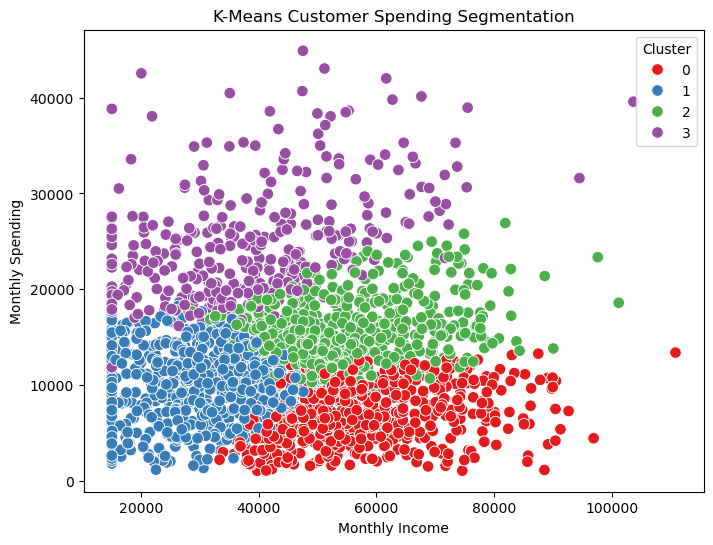

In [67]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Monthly_Income',
    y='Monthly_Spending',
    hue='Cluster',
    palette='Set1',
    s=70
)

plt.title("K-Means Customer Spending Segmentation")
plt.xlabel("Monthly Income")
plt.ylabel("Monthly Spending")
plt.legend(title="Cluster")

plt.show()

# DBSCAN

In [41]:
from sklearn.cluster import DBSCAN

In [43]:
dbscan = DBSCAN(eps=0.5, min_samples=5)

In [44]:
dbscan_labels = dbscan.fit_predict(x_scaled)

In [45]:
df['DBSCAN_Cluster'] = dbscan_labels

In [46]:
df['DBSCAN_Cluster'].value_counts().sort_index()

DBSCAN_Cluster
-1    2195
 0       5
Name: count, dtype: int64

In [47]:
df['DBSCAN_Cluster'].value_counts().sort_index()

DBSCAN_Cluster
-1    2195
 0       5
Name: count, dtype: int64

In [48]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

In [50]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(x_scaled)

distances, indices = neighbors_fit.kneighbors(x_scaled)

In [51]:
distances = np.sort(distances[:, 4])

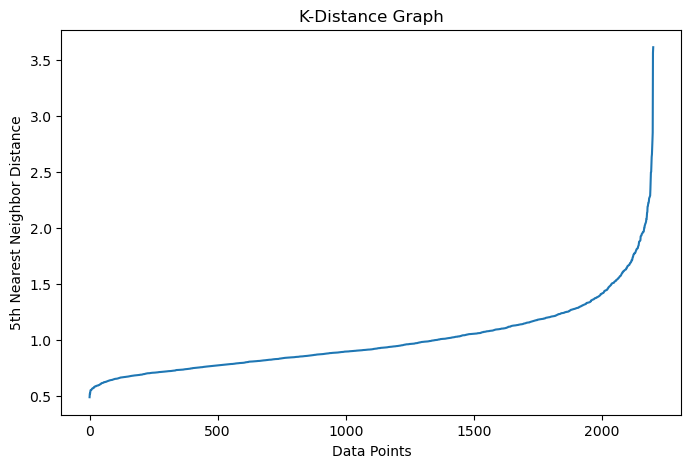

In [52]:
plt.figure(figsize=(8,5))

plt.plot(distances)

plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Graph")

plt.show()

In [53]:
dbscan = DBSCAN(eps=0.8, min_samples=5)

In [54]:
dbscan = DBSCAN(eps=0.6, min_samples=5)

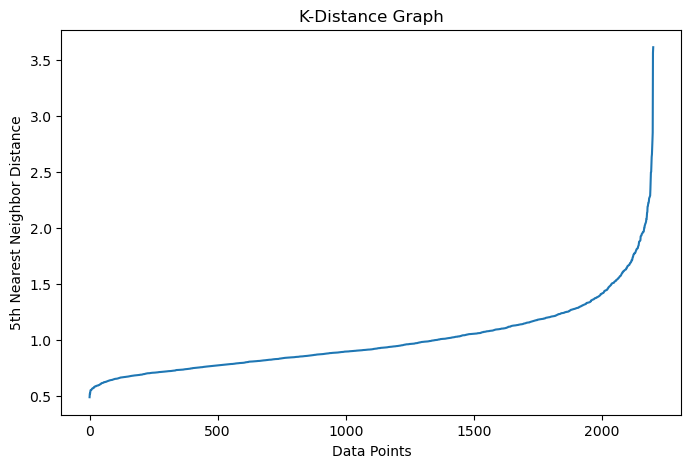

In [56]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(x_scaled)

distances, indices = neighbors_fit.kneighbors(x_scaled)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(8,5))
plt.plot(distances)

plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Graph")

plt.show()

In [58]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(x_scaled)

In [59]:
df['DBSCAN_Cluster'] = dbscan_labels

In [60]:
df['DBSCAN_Cluster'].value_counts().sort_index()

DBSCAN_Cluster
-1     1189
 0      910
 1        5
 2        7
 3       10
 4        9
 5        7
 6        7
 7        6
 8       10
 9        5
 10       4
 11       4
 12       9
 13       5
 14       5
 15       5
 16       3
Name: count, dtype: int64

In [61]:
outliers = (df['DBSCAN_Cluster'] == -1).sum()

print("Number of outliers:", outliers)

Number of outliers: 1189


In [62]:
labels = df['DBSCAN_Cluster']

n_clusters = len(set(labels)) - (1 if -1 in labels.values else 0)

print("Number of clusters:", n_clusters)

Number of clusters: 17


In [64]:
from sklearn.metrics import silhouette_score

mask = labels != -1

if len(set(labels[mask])) > 1:
    dbscan_score = silhouette_score(
        x_scaled[mask],
        labels[mask]
    )
    print("DBSCAN Silhouette Score:", dbscan_score)
else:
    print("Silhouette Score cannot be calculated because DBSCAN found fewer than 2 clusters.")

DBSCAN Silhouette Score: -0.24167233627405466


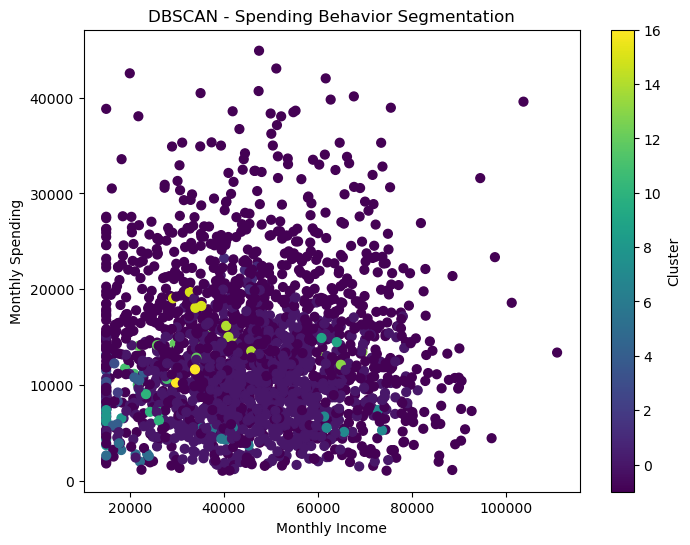

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Monthly_Income'],
    df['Monthly_Spending'],
    c=df['DBSCAN_Cluster'],
    cmap='viridis',
    s=40
)

plt.xlabel("Monthly Income")
plt.ylabel("Monthly Spending")
plt.title("DBSCAN - Spending Behavior Segmentation")

plt.colorbar(label="Cluster")
plt.show()

In [66]:
dbscan_summary = df[df['DBSCAN_Cluster'] != -1].groupby(
    'DBSCAN_Cluster'
)[features].mean().round(2)

dbscan_summary

,Monthly_Income,Monthly_Spending,Purchase_Frequency,Average_Purchase_Amount,Online_Spending,Offline_Spending,Savings,Discount_Usage_Percent
DBSCAN_Cluster,,,,,,,,
0,45996.17,9815.10,7.14,1551.06,4838.12,4989.57,41101.85,33.61
1,44600.70,21719.20,9.00,2830.60,15217.60,6501.60,25137.60,14.40
2,16319.86,8699.43,6.86,1304.14,2861.29,5838.14,11839.43,50.43
3,15416.10,10638.80,6.50,1827.20,4101.40,6537.40,9991.60,26.90
4,18553.56,8545.56,8.56,1220.22,3460.56,5085.00,12606.89,29.00
5,20297.71,2834.57,4.57,646.86,1392.57,1442.00,19902.29,55.00
6,40698.86,4671.29,4.14,1365.71,2569.29,2102.00,40551.57,15.86
7,66574.33,6064.50,4.00,2134.00,3463.33,2601.17,69005.83,33.83
8,15323.00,6305.60,4.80,1560.90,2890.50,3415.10,14896.50,36.60
